# Sentiment Analysis of Financial News Headlines
## This task tests your ability to apply NLP techniques you've learnt to classify a news headline containing financial information into either one of the sentiments (Positive, Negative or Neutral)

### Dataset:
https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv

## Max Marks without Bonus attempted: 80 points
## Max Marks with Bonus: 100 points
- ### Bonus: 20 points

### Steps
- 1. Download the dataset
- 2. Load the dataset
- 3. Explore the dataset (Exploratory Data Analysis)
- 4. Clean the data
- 5. Apply SMOTE for imbalanced data [Optional] --> Carries Bonus Marks
- 6. Build a BoW model
- 7. Build a Tf-Idf model
- 8. Split train and test data
- 9. Use one ML Classifying algorithm to classify the finanical news headline data
- 10. Use another ML classifying algorithm to classify them
- 11. Plot Confusion matrix

## 1. Download the dataset [1 point]

In [15]:
!pip install imblearn
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from imblearn.over_sampling import SMOTE

# Download NLTK resources (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt')

# Download the dataset
!wget https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


--2025-03-28 22:56:25--  https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 672006 (656K) [application/octet-stream]
Saving to: ‘financial_news_headlines_sentiment.csv.4’

financial_news_head 100%[===================>] 656.26K  --.-KB/s    in 0.05s   

2025-03-28 22:56:25 (11.8 MB/s) - ‘financial_news_headlines_sentiment.csv.4’ saved [672006/672006]



## 2. Load the dataset [1 point]

In [8]:
# Load the dataset into a pandas DataFrame called 'df'
df = pd.read_csv('financial_news_headlines_sentiment.csv', encoding='latin-1', header=0, names=['Sentiment', 'Sentence'])

## 3. Explore the dataset [10 points]

In [9]:
# Check the actual column names in the DataFrame
print(df.columns)

# Display the first 5 rows of the dataset
df.head()

# Display the last 5 rows of the dataset
df.tail()

# Get the shape of the dataset (number of rows, number of columns)
df.shape

# Get information about the dataset, including data types and missing values
df.info()

# Get descriptive statistics for numerical columns
df.describe()

# Get the number of unique values in each column
df.nunique()

# Get the value counts for the 'Sentiment' column
df['Sentiment'].value_counts()

Index(['Sentiment', 'Sentence'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  4845 non-null   object
 1   Sentence   4845 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


,count
Sentiment,
neutral,2878
positive,1363
negative,604


## 4. Clean the data [5 points]

In [12]:

def clean_text(text):
    """
    Cleans the input text by removing punctuation, converting to lowercase,
    and removing stop words.
    """
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]
    cleaned_text = ' '.join(cleaned_words)

    return cleaned_text

# Apply the clean_text function to the 'Sentence' column
df['Cleaned_Sentence'] = df['Sentence'].apply(clean_text)

## 5. SMOTE (Imbalanced dataset) [OPTIONAL] BONUS [20 points]
Hint: Use **imblearn** library

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Cleaned_Sentence'])
y = df['Sentiment']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


## 6. BoW model [15 points]

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer object
vectorizer = CountVectorizer()

# Fit the vectorizer to your cleaned text data
# This creates the vocabulary based on the words in your dataset
vectorizer.fit(df['Cleaned_Sentence'])

# Transform text data into a BoW representation
bow_features = vectorizer.transform(df['Cleaned_Sentence'])


## 7. Tf-idf model [15 points]

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TfidfVectorizer object
tfidf_vectorizer = TfidfVectorizer()

# Fit the vectorizer to your cleaned text data
tfidf_vectorizer.fit(df['Cleaned_Sentence'])

tfidf_features = tfidf_vectorizer.transform(df['Cleaned_Sentence'])


## 8. Split train test data [3 points]

In [29]:
from sklearn.model_selection import train_test_split

# For BoW features:
X_train, X_test, y_train, y_test = train_test_split(bow_features, df['Sentiment'], test_size=0.2, random_state=42)



## 9. Classification Algorithm [10 points]
- Train
- Predict

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create a Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)  # Increase max_iter if needed

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7327141382868937


## 10. Another Classification Algorithm [10 points]
- Train
- Predict

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest Classifier model
model_rf = RandomForestClassifier(random_state=42)

# Train the model using the training data
model_rf.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_rf = model_rf.predict(X_test)

# Evaluate the model's accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy (Random Forest): {accuracy_rf}")

Accuracy (Random Forest): 0.7203302373581011


## 11. Confusion Matrixes for two classification algorithms and two feature extractor methods [10 points]

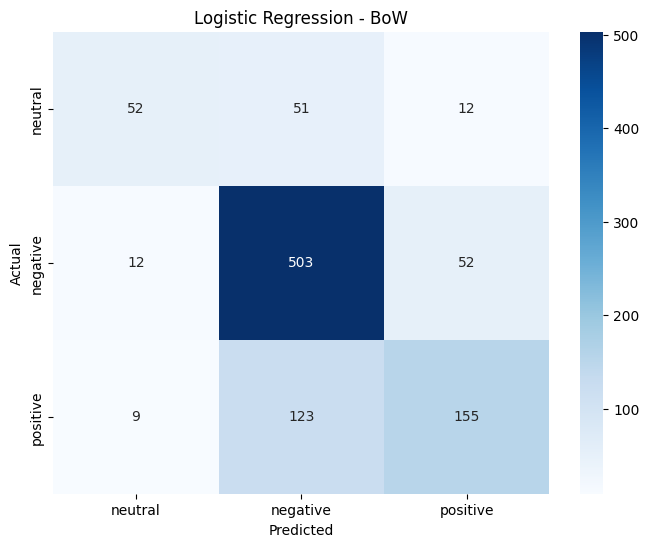

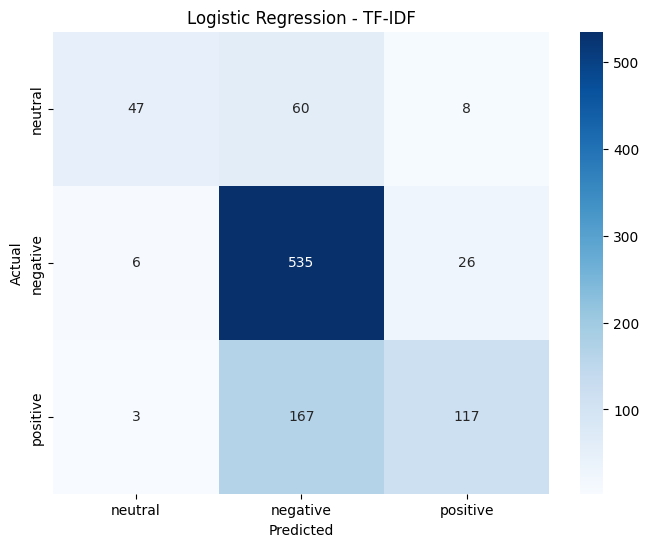

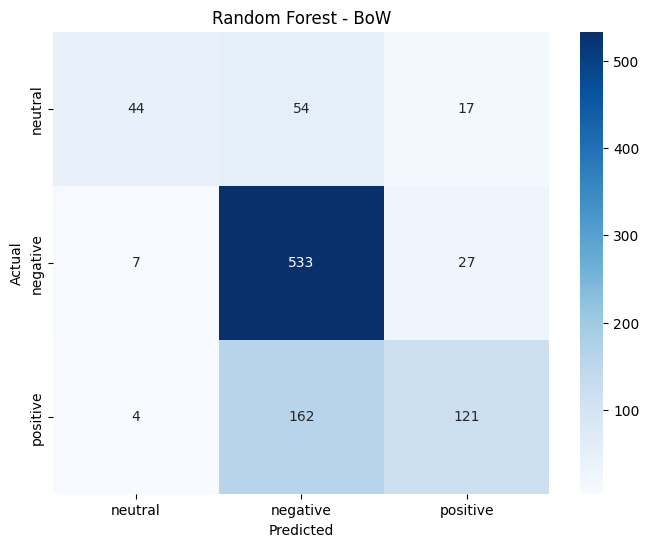

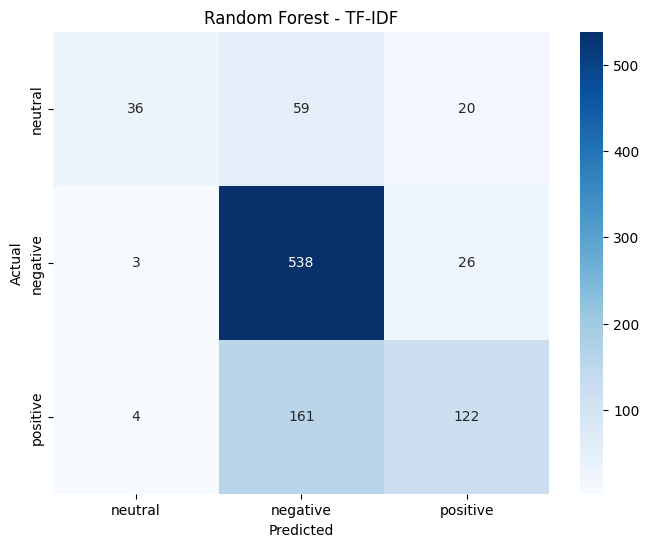

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=df['Sentiment'].unique(),
                yticklabels=df['Sentiment'].unique())
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# --- Logistic Regression ---
# BoW Features
plot_confusion_matrix(y_test, y_pred, "Logistic Regression - BoW")

# TF-IDF Features
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(tfidf_features, df['Sentiment'], test_size=0.2, random_state=42)
model_tfidf = LogisticRegression(max_iter=1000, random_state=42)
model_tfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
plot_confusion_matrix(y_test_tfidf, y_pred_tfidf, "Logistic Regression - TF-IDF")

# --- Random Forest ---
# BoW Features
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest - BoW")

# TF-IDF Features
model_rf_tfidf = RandomForestClassifier(random_state=42)
model_rf_tfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_rf_tfidf = model_rf_tfidf.predict(X_test_tfidf)
plot_confusion_matrix(y_test_tfidf, y_pred_rf_tfidf, "Random Forest - TF-IDF")